# PyTorch Sequence Modeling for HCP Classification

This notebook implements a Cross-Validation training loop over the generated 3D tensors. We utilize the `HCPSequenceModel` which features a 1D-CNN combined with a GRU, optimized via `AdamW` and a `FocalLoss` function to handle class imbalance.

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os

# Ensure src/ is in the path
sys.path.append("../src")
from model import HCPSequenceModel
from loss import FocalLoss
from dataset import HCPDataset, get_dataloader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [27]:
# Setup Paths
BASE_DIR = Path("../../").resolve()
TENSORS_DIR = BASE_DIR / "/1d-CNN/data/tensors/"
CHECKPOINTS_DIR = Path("/Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/1d-CNN/checkpoints")
checkpoints_path = Path(CHECKPOINTS_DIR)

print("Loading Tensors...")
X_tensor = torch.load("/Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/1d-CNN/tensors/X_features.pt")
y_tensor = torch.load("/Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/1d-CNN/tensors/y_labels.pt")
folds = torch.load("/Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/1d-CNN/tensors/folds.pt")

print(f"Loaded X: {X_tensor.shape}, y: {y_tensor.shape}")

num_features = X_tensor.shape[2]
num_classes = 3

Loading Tensors...
Loaded X: torch.Size([20931, 86, 65]), y: torch.Size([20931])


In [28]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
        
    epoch_loss = total_loss / len(dataloader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, f1

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
    epoch_loss = total_loss / len(dataloader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, f1, all_preds, all_labels

In [29]:
# Cross-Validation Loop
num_epochs = 15
batch_size = 128
oof_predictions = np.zeros(len(y_tensor))
oof_labels = np.zeros(len(y_tensor))

for fold in range(5):
    print(f"\n{'='*20} FOLD {fold} {'='*20}")
    
    # Exclude unlabeled data (fold == -1) from the training set
    train_idx = ((folds != fold) & (folds != -1)).nonzero(as_tuple=True)[0]
    val_idx = ((folds == fold) & (folds != -1)).nonzero(as_tuple=True)[0]
    
    X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
    X_val, y_val = X_tensor[val_idx], y_tensor[val_idx]
    
    # Use an on-the-fly PyTorch TensorDataset equivalent for memory efficiency
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = HCPSequenceModel(input_features=num_features, hidden_size=64, num_classes=num_classes).to(device)
    
    criterion = FocalLoss(alpha=torch.tensor([0.1, 0.4, 0.5]), gamma=3.0).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_val_f1 = 0.0
    
    for epoch in range(num_epochs):
        train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, val_preds, val_lbls = evaluate_epoch(model, val_loader, criterion, device)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            save_path = os.path.join(CHECKPOINTS_DIR, f"model_fold_{fold}.pth")
            # Alternatively: save_path = f"{CHECKPOINTS_DIR}/model_fold_{fold}.pth"
    
            torch.save(model.state_dict(), save_path)
            
            # Save best predictions for OOF
            oof_predictions[val_idx.numpy()] = val_preds
            oof_labels[val_idx.numpy()] = val_lbls


==================== FOLD 0 ====================
Epoch 01 | Train Loss: 0.0097 | Train F1: 0.1207 | Val Loss: 0.0063 | Val F1: 0.1432
Epoch 02 | Train Loss: 0.0055 | Train F1: 0.1636 | Val Loss: 0.0050 | Val F1: 0.1697
Epoch 03 | Train Loss: 0.0050 | Train F1: 0.1969 | Val Loss: 0.0049 | Val F1: 0.1978
Epoch 04 | Train Loss: 0.0049 | Train F1: 0.2061 | Val Loss: 0.0049 | Val F1: 0.2009
Epoch 05 | Train Loss: 0.0049 | Train F1: 0.2195 | Val Loss: 0.0049 | Val F1: 0.2056
Epoch 06 | Train Loss: 0.0048 | Train F1: 0.2215 | Val Loss: 0.0049 | Val F1: 0.2200
Epoch 07 | Train Loss: 0.0048 | Train F1: 0.2289 | Val Loss: 0.0048 | Val F1: 0.2141
Epoch 08 | Train Loss: 0.0048 | Train F1: 0.2327 | Val Loss: 0.0048 | Val F1: 0.2180
Epoch 09 | Train Loss: 0.0048 | Train F1: 0.2394 | Val Loss: 0.0048 | Val F1: 0.2095
Epoch 10 | Train Loss: 0.0048 | Train F1: 0.2360 | Val Loss: 0.0048 | Val F1: 0.2256
Epoch 11 | Train Loss: 0.0047 | Train F1: 0.2425 | Val Loss: 0.0048 | Val F1: 0.2149
Epoch 12 | Trai


--- Out-of-Fold (OOF) Classification Report ---
              precision    recall  f1-score   support

         0.0     1.0000    0.5850    0.7382     15438
         1.0     0.3094    0.4700    0.3732      3349
         2.0     0.2361    0.7500    0.3591      2144

    accuracy                         0.5835     20931
   macro avg     0.5152    0.6017    0.4902     20931
weighted avg     0.8113    0.5835    0.6410     20931



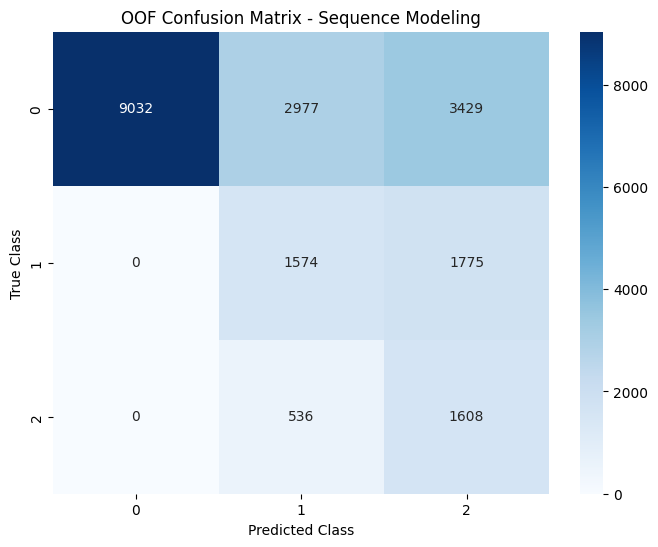

In [33]:
# Out-of-Fold (OOF) Evaluation
print("\n--- Out-of-Fold (OOF) Classification Report ---")
print(classification_report(oof_labels, oof_predictions, digits=4))

# Confusion Matrix
cm = confusion_matrix(oof_labels, oof_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("OOF Confusion Matrix - Sequence Modeling")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()


--- Out-of-Fold (OOF) Classification Report ---
              precision    recall  f1-score   support

         0.0     1.0000    0.5850    0.7382     15438
         1.0     0.3094    0.4700    0.3732      3349
         2.0     0.2361    0.7500    0.3591      2144

    accuracy                         0.5835     20931
   macro avg     0.5152    0.6017    0.4902     20931
weighted avg     0.8113    0.5835    0.6410     20931



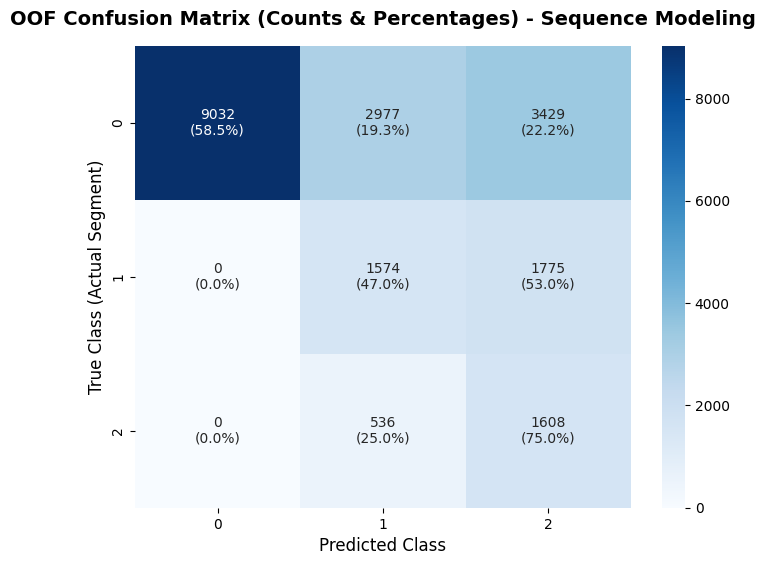

In [34]:
import numpy as np

# Out-of-Fold (OOF) Evaluation
print("\n--- Out-of-Fold (OOF) Classification Report ---")
print(classification_report(oof_labels, oof_predictions, digits=4))

# Confusion Matrix
cm = confusion_matrix(oof_labels, oof_predictions)

# Calculate row-wise percentages (Recall per class)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create an array of strings combining the raw count and the percentage
annot_data = [f"{count}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_percentages.flatten())]
annot_data = np.asarray(annot_data).reshape(cm.shape)

plt.figure(figsize=(8, 6))
# We pass 'cm' for the color scale, but 'annot_data' for the text inside the boxes
sns.heatmap(cm, annot=annot_data, fmt='', cmap='Blues')
plt.title("OOF Confusion Matrix (Counts & Percentages) - Sequence Modeling", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("True Class (Actual Segment)", fontsize=12)
plt.xlabel("Predicted Class", fontsize=12)
plt.show()